<a href="https://colab.research.google.com/github/JaskarJeyabalan/Swiggy_Sales_Analysis/blob/main/notebooks/01_data_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 - Data Audit: Swiggy Jan-Aug 2025

**Goal:** understand and document the data *before* any analysis. This notebook only audits; it changes nothing.

**Dataset:** `Swiggy_Data.csv` - Swiggy Jan-Aug2025 Dataset.

Set `DATA_PATH` below to where the CSV is on your computer.

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

DATA_PATH = '/content/Swiggy_Data.csv'

df = pd.read_csv(DATA_PATH)
df.columns = ['State','City','Order_Date','Restaurant_Name','Location','Category','Dish_Name','Price_INR','Rating','Rating_Count']
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')   # the file stores dates as dd-mm-yyyy
print(df.shape)
df.head()

(197430, 10)


,State,City,Order_Date,Restaurant_Name,Location,Category,Dish_Name,Price_INR,Rating,Rating_Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


## 1. Structure, missing values, duplicates

In [ ]:
print(df.dtypes, '\n')
print('Missing values per column:'); print(df.isna().sum().to_string(), '\n')
blank = {c: int((df[c].astype(str).str.strip() == '').sum()) for c in ['State','City','Restaurant_Name','Location','Category','Dish_Name']}
print('Blank text values:', blank)
dups = int(df.duplicated().sum())
print(f'\nExact duplicate rows: {dups}  (rows: {len(df):,} -> {len(df)-dups:,} if removed)')

State                      object
City                       object
Order_Date         datetime64[ns]
Restaurant_Name            object
Location                   object
Category                   object
Dish_Name                  object
Price_INR                 float64
Rating                    float64
Rating_Count                int64
dtype: object 

Missing values per column:
State              0
City               0
Order_Date         0
Restaurant_Name    0
Location           0
Category           0
Dish_Name          0
Price_INR          0
Rating             0
Rating_Count       0 

Blank text values: {'State': 0, 'City': 0, 'Restaurant_Name': 0, 'Location': 0, 'Category': 0, 'Dish_Name': 0}

Exact duplicate rows: 27  (rows: 197,430 -> 197,403 if removed)


**Finding 1 - the file is complete:** no missing values and no blanks. There are a few exact duplicate rows (27 here; 29 once the SQL trims text and rounds prices). The data has **no order id**, so we cannot prove those are real duplicates (they could be repeat orders). Decision: remove exact copies (a tiny share) and say so in the README.

## 2. Coverage: dates, geography, scale

In [ ]:
print('Date range:', df.Order_Date.min().date(), '->', df.Order_Date.max().date(), '| distinct days:', df.Order_Date.nunique())
print('Expected days in range:', (df.Order_Date.max() - df.Order_Date.min()).days + 1)
print(f"States: {df.State.nunique()} | Cities: {df.City.nunique()} | Restaurants (names): {df.Restaurant_Name.nunique():,} | "
      f"Outlets (name+location): {df.groupby(['Restaurant_Name','Location']).ngroups:,} | Dishes: {df.Dish_Name.nunique():,}")
print('Rows per month:'); print(df.groupby(df.Order_Date.dt.to_period('M')).size().to_string())

Date range: 2025-01-01 -> 2025-08-31 | distinct days: 243
Expected days in range: 243
States: 28 | Cities: 28 | Restaurants (names): 993 | Outlets (name+location): 2,199 | Dishes: 59,064
Rows per month:
Order_Date
2025-01    25398
2025-02    23296
2025-03    24402
2025-04    24588
2025-05    25190
2025-06    24385
2025-07    24940
2025-08    25231
Freq: M


**Finding 2 - the data covers 8 months only (1 Jan - 31 Aug 2025).** Every day is present. The Q3 has only two months, quarters must be compared per day, not in total.

## 3. Rows per day and the 22 February anomaly

Median rows per day: 811 | max: 1,550 on 2025-02-22
Days > 1.5 x median: {'2025-02-22': 1550}


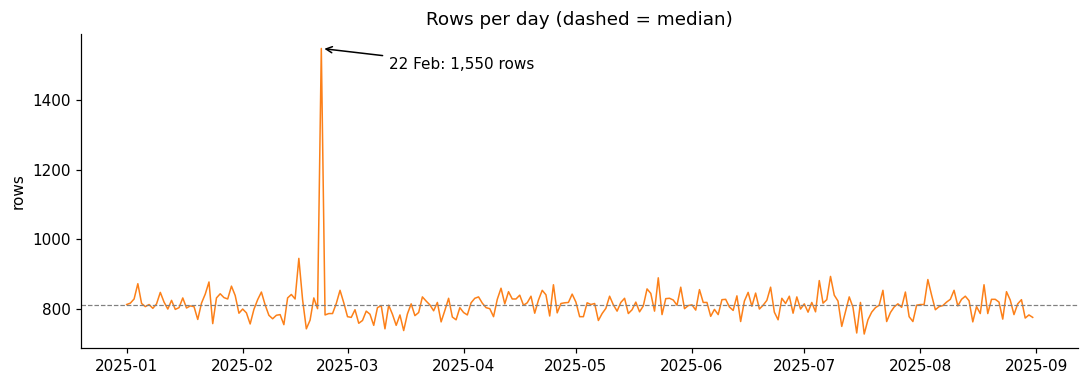

Bengaluru on 22 Feb: 827 rows vs 80 on a normal day (10.4x)
All other cities on 22 Feb: 723 rows vs 730 normal (0.99x)


In [ ]:
daily = df.groupby('Order_Date').size()
med = daily.median()
print(f'Median rows per day: {med:.0f} | max: {daily.max():,} on {daily.idxmax().date()}')
anom = daily[daily > 1.5 * med]; print('Days > 1.5 x median:', {str(k.date()): int(v) for k, v in anom.items()})

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(daily.index, daily.values, color='#FC8019', lw=1)
ax.axhline(med, color='grey', ls='--', lw=.8)
ax.annotate('22 Feb: 1,550 rows', xy=(pd.Timestamp('2025-02-22'), daily.max()), xytext=(pd.Timestamp('2025-03-12'), daily.max()-60),
            arrowprops=dict(arrowstyle='->'))
ax.set_title('Rows per day (dashed = median)'); ax.set_ylabel('rows'); plt.tight_layout(); plt.show()

a = df[df.Order_Date == '2025-02-22']; typ = df[df.Order_Date != '2025-02-22']
bl = (a.City == 'Bengaluru').sum(); bl_typ = (typ.City == 'Bengaluru').sum() / typ.Order_Date.nunique()
oth = (a.City != 'Bengaluru').sum(); oth_typ = (typ.City != 'Bengaluru').sum() / typ.Order_Date.nunique()
print(f'Bengaluru on 22 Feb: {bl} rows vs {bl_typ:.0f} on a normal day ({bl/bl_typ:.1f}x)')
print(f'All other cities on 22 Feb: {oth} rows vs {oth_typ:.0f} normal ({oth/oth_typ:.2f}x)')

**Finding 3 - 22 Feb 2025 is a data anomaly caused by one city.** Bengaluru has about 10 times its normal volume that day while every other city is normal, which looks like a source/loading problem, not a real surge. This is in the *original* file. Decision: keep the rows but **flag the day** (`Is_Anomaly_Day`) and exclude it from daily/weekly trends and any forecast.

## 4. Price

count    197430.0
mean        268.5
std         219.3
min           1.0
1%           24.2
5%           60.0
25%         139.0
50%         229.0
75%         329.0
95%         614.9
99%        1100.0
max        8000.0

Price < 10: 214 rows (min 0.95) | Price > 2000: 338 rows (max 8,000)
Share of total value from the top 1% of prices: 6.1%


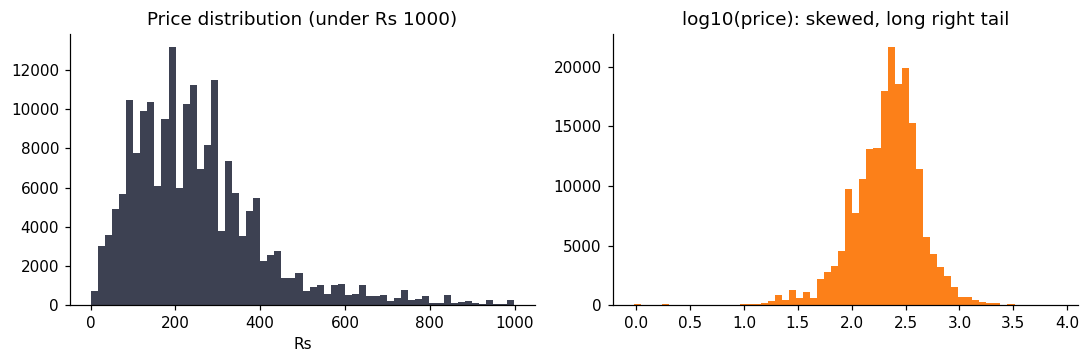

In [ ]:
p = df.Price_INR
print(p.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(1).to_string())
print(f'\nPrice < 10: {(p<10).sum()} rows (min {p.min()}) | Price > 2000: {(p>2000).sum()} rows (max {p.max():,.0f})')
print(f'Share of total value from the top 1% of prices: {p[p >= p.quantile(.99)].sum() / p.sum():.1%}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(p[p < 1000], bins=60, color='#3d4152'); ax[0].set_title('Price distribution (under Rs 1000)'); ax[0].set_xlabel('Rs')
ax[1].hist(np.log10(p), bins=60, color='#FC8019'); ax[1].set_title('log10(price): skewed, long right tail'); plt.tight_layout(); plt.show()

**Finding 4 - prices are strongly right-skewed.** The median (about Rs 229) is lower than the mean (about Rs 268); a few very large prices (up to Rs 8,000) are probably party packs or combos. Decision: keep them (they look real), but report **median as well as mean**, and be careful with averages. Prices below Rs 10 (a few hundred rows) are probably add-ons such as extra sauces.

## 5. Rating and Rating_Count - the most important check

Rating range: 1.5 - 5.0 | values above 5: 0
Rating_Count == 0: 79,094 rows (40.1%)

Most common ratings when Rating_Count == 0:
Rating
4.4    75063
4.3     2239
4.1      571
4.0      365
4.5      273

Share of zero-review rows with rating exactly 4.4: 94.9%

Most common ratings when Rating_Count > 0:
Rating
4.3    11459
4.6    10602
4.4    10593
4.5     9674
5.0     9403

Average rating - all rows: 4.34 | rows with reviews only: 4.31


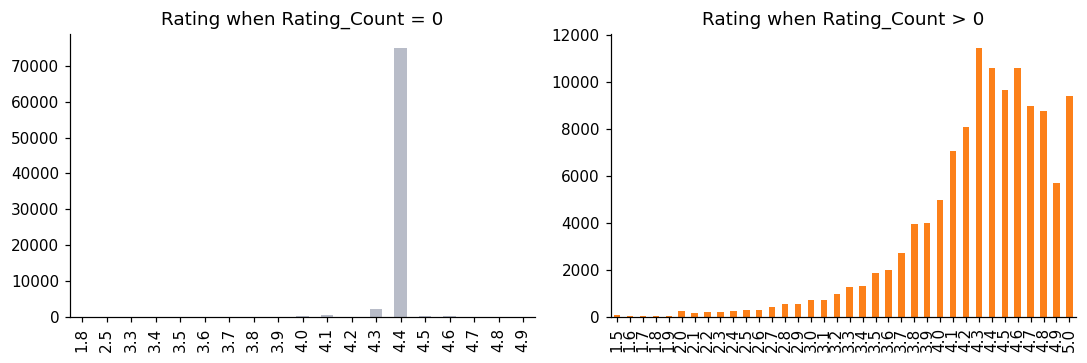

In [ ]:
rc = df.Rating_Count
print('Rating range:', df.Rating.min(), '-', df.Rating.max(), '| values above 5:', int((df.Rating > 5).sum()))
print(f'Rating_Count == 0: {(rc==0).sum():,} rows ({(rc==0).mean():.1%})')
print('\nMost common ratings when Rating_Count == 0:'); print(df[rc == 0].Rating.value_counts().head(5).to_string())
share44 = (df[rc == 0].Rating == 4.4).mean()
print(f'\nShare of zero-review rows with rating exactly 4.4: {share44:.1%}')
print('\nMost common ratings when Rating_Count > 0:'); print(df[rc > 0].Rating.value_counts().head(5).to_string())
print(f'\nAverage rating - all rows: {df.Rating.mean():.2f} | rows with reviews only: {df[rc>0].Rating.mean():.2f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
df[rc == 0].Rating.round(1).value_counts().sort_index().plot.bar(ax=ax[0], color='#b8bcc8'); ax[0].set_title('Rating when Rating_Count = 0'); ax[0].set_xlabel('')
df[rc > 0].Rating.round(1).value_counts().sort_index().plot.bar(ax=ax[1], color='#FC8019'); ax[1].set_title('Rating when Rating_Count > 0'); ax[1].set_xlabel('')
plt.tight_layout(); plt.show()

**Finding 5 - 40% of the ratings are a placeholder, not a real rating.** About 40% of rows have 0 reviews, and almost all of them show the exact same rating, 4.4 - a default value. Averaging them in makes the overall rating look more certain than it is. Decision: set the rating to `NULL` when `Rating_Count = 0` (status "Not Rated") and report ratings only for reviewed items (also a version weighted by review count). The old project capped invalid ratings at 5 instead of questioning them - that is the kind of mistake this audit exists to prevent.

## 6. What is one row? (data grain)

In [ ]:
listing = df.groupby(['Restaurant_Name', 'Location', 'Dish_Name']).size()
print(f'Distinct (restaurant, location, dish) combinations: {len(listing):,} for {len(df):,} rows')
print(f'Combinations that appear only once: {(listing == 1).mean():.0%}')
print(f'Average rows per combination: {listing.mean():.2f}')
same_day = df.groupby(['Restaurant_Name', 'Location', 'Dish_Name', 'Order_Date']).size()
print(f'Same dish, same outlet, same day appearing more than once: {(same_day > 1).sum()} cases')

Distinct (restaurant, location, dish) combinations: 176,694 for 197,430 rows
Combinations that appear only once: 89%
Average rows per combination: 1.12
Same dish, same outlet, same day appearing more than once: 103 cases


**Finding 6 - the meaning of a row is not fully clear.** There is no order id, and almost every dish-at-an-outlet appears only once, while `Rating` and `Rating_Count` look like item-level information. A row is therefore best described as **one dish line item (an order record)**, not a verified customer order. Consequences for the whole project:

- say **"order records"** and **"sales value (sum of item prices)"**, not "orders" and "revenue" of Swiggy;
- average order value = average item price in this dataset;
- do not extrapolate to real company revenue. State this limitation in the README.

## 7. Text quality (why dish names need a normalised key)

In [ ]:
dn = df.Dish_Name.astype(str)
print('Dish names with non-English characters:', int(dn.str.contains(r'[^\x00-\x7F]').sum()))
print('Dish names containing a comma or quote:', int(dn.str.contains(r'[,"]').sum()))
print('Dish names with brackets / sizes e.g. [500g], (2 pcs):', int(dn.str.contains(r'[\[\(]').sum()))
print('Longest dish name:', dn.str.len().max(), 'characters')
print('Distinct dish names:', dn.nunique(), '| after lower-casing:', dn.str.lower().nunique())
print('\nExamples:'); print(dn[dn.str.contains(r'[\[\(]')].drop_duplicates().head(5).to_string())

Dish names with non-English characters: 2147
Dish names containing a comma or quote: 2846
Dish names with brackets / sizes e.g. [500g], (2 pcs): 36819
Longest dish name: 196 characters
Distinct dish names: 59064 | after lower-casing: 56588

Examples:
16                 Navarathna Kurma (Sweet Dish)
19                Dum Aloo Kashmiri (Sweet Dish)
49               Kashmiri Biriyani ( Sweet Rice)
105                   Kasmiri Naan (Sweet Bread)
241    Thalassery Chicken Dum Biryani [Serves 1]


**Finding 7 - dish names are messy** (brackets, sizes, symbols, other scripts, inconsistent case). For classifying Veg/Non-Veg, cuisine and meal role, the SQL builds a cleaned *key* (lower-case, punctuation removed, whole-word matching) and leaves the original display name untouched. Whole-word matching fixes the earlier bugs: "veggie" no longer matches "egg", "steam rice" no longer matches "tea", "classic" no longer matches "lassi", and "banana" is no longer turned into "banaana".

## 8. Decisions summary (goes into the README)

| # | Issue | Evidence | Decision |
|---|---|---|---|
| 1 | Exact duplicate rows | 27 in the raw file; 29 once text is trimmed and prices rounded (as in SQL) | Remove; document (no order id) |
| 2 | Only Jan-Aug 2025 | 243 days | Say "Jan-Aug 2025" everywhere; compare quarters per day |
| 3 | 22 Feb volume spike | 1,550 rows, Bengaluru 10x | Keep, flag, exclude from trends/forecast |
| 4 | Skewed prices | median Rs 229 vs mean Rs 268 | Report median and mean |
| 5 | Placeholder rating 4.4 | 40% of rows, count = 0 | Rating = NULL when no reviews |
| 6 | Row meaning unclear | no order id, items appear once | "Order records" / "sales value"; state limitation |
| 7 | Messy dish names | symbols, non-English | Normalised key, whole-word rules, keep display name |

**Next:** 02 - cleaning and feature engineering in Python (mirrors the SQL), then EDA, then a small honest forecast.